**LAB 1 : Probability distributions and descriptive statistics**

### Library import

In [2]:
import numpy as np # math library
import pandas as pd # Library to handle databases
import matplotlib.pyplot as plt # Graphic library
from scipy import stats # stat library
import seaborn as sns #Graphic library specialized in stats
import statsmodels.api as sm

# Download library with tools for learning
# Only when used on Linux or Colab. Otherwise get the files manually from the url.
!wget --quiet --no-check-certificate 'https://docs.google.com/uc?export=download&id=1rmMQN9kNc-lZLEgWc-EuTxnRsRkvVzRs' -O learntools.zip
!unzip -qq learntools.zip
!wget --quiet --no-check-certificate 'https://docs.google.com/uc?export=download&id=1QK8R4C0pFlz2pwRxCbW3K7vBk4D7jqD9' -O TP1.py

from learntools.core import binder # Library with learning tools
binder.bind(globals())
from TP1 import *

zsh:1: command not found: wget
unzip:  cannot find or open learntools.zip, learntools.zip.zip or learntools.zip.ZIP.
zsh:1: command not found: wget


/Users/olutolaoloruntobipaul/Desktop/Projects/Applied-Statistics/TP1.py:52: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(x,norm(0,1).pdf(x), label='$\sigma^2=1$')


# Probability laws with python

In python, we can use the library scipy as a probability toolbox, see https://docs.scipy.org/doc/scipy/reference/stats.html. The general use is to find the law that we want to use, let us consider the normal for example and to use the functions from the library. The cumulative distribution function (CDF) of a random variable X is defined by $F(x) =P(X\le x)$, for any $x\in \mathbb{R}$. For discrete law, the probability density function (PDF) is $P(X=x)$. If the law is continuous, the PDF is defined as the derivative of the CDF $f(x)=F'(x)$.

Theorical mean: 2.00
Theorical variance: 9.00


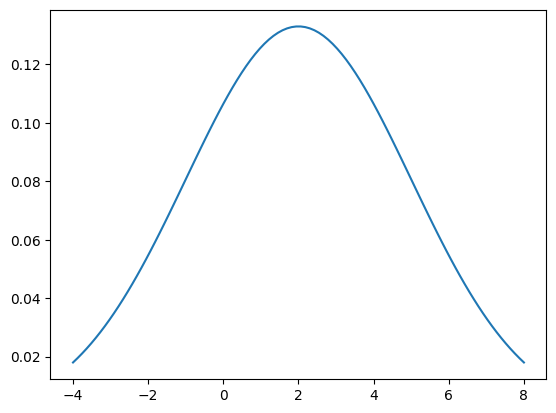

In [3]:
from scipy.stats import norm
law = norm(2,3)
mean, var = law.stats(moments='mv') # m stands for mean, v for variance
print("Theorical mean: %.2F" %mean)
print("Theorical variance: %.2F" %var)

# From the help, law.cdf is the CDF of the law, law.ppf is the inverse CDF (quantile) of the law,
# law.pdf is its pdf...
x = np.linspace(-4, 8, num=100)
plt.plot(x, law.pdf(x), label='norm pdf')

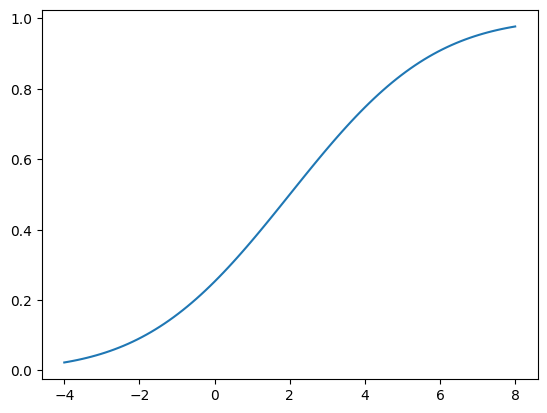

In [4]:
plt.plot(x, law.cdf(x), label='norm cdf')

### Question 1
Print the mean and the variance of a Gamma with parameter a=1/2 (see https://docs.scipy.org/doc/scipy/reference/stats.html).

Plot the PDF and CDF of this Gamma distribution.

Do the same with parameter a=2 and loc=1. Comment the resulting plots.

Gamma(a=1/2): mean = 0.500, variance = 0.500
Gamma(a=2, loc=1): mean = 3.000, variance = 2.000


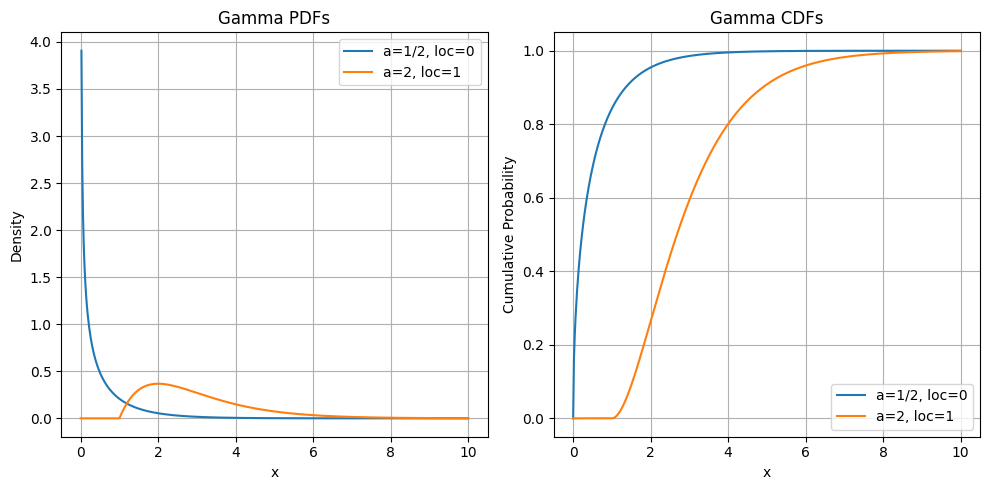

In [8]:
# Answer here

# --- Case 1: a = 1/2 ---
a1 = 0.5
dist1 = stats.gamma(a=a1)

mean1, var1 = dist1.mean(), dist1.var()
print(f"Gamma(a=1/2): mean = {mean1:.3f}, variance = {var1:.3f}")

x = np.linspace(0, 10, 500)
pdf1 = dist1.pdf(x)
cdf1 = dist1.cdf(x)

# --- Case 2: a = 2, loc = 1 ---
a2, loc2 = 2, 1
dist2 = stats.gamma(a=a2, loc=loc2)

mean2, var2 = dist2.mean(), dist2.var()
print(f"Gamma(a=2, loc=1): mean = {mean2:.3f}, variance = {var2:.3f}")

pdf2 = dist2.pdf(x)
cdf2 = dist2.cdf(x)

# --- Plotting ---
plt.figure(figsize=(10, 5))

# PDF plots
plt.subplot(1, 2, 1)
plt.plot(x, pdf1, label='a=1/2, loc=0')
plt.plot(x, pdf2, label='a=2, loc=1')
plt.title("Gamma PDFs")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.grid(True)

# CDF plots
plt.subplot(1, 2, 2)
plt.plot(x, cdf1, label='a=1/2, loc=0')
plt.plot(x, cdf2, label='a=2, loc=1')
plt.title("Gamma CDFs")
plt.xlabel("x")
plt.ylabel("Cumulative Probability")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [9]:
# Uncomment the following line to get the solution.
Q_1.solution()

<IPython.core.display.Javascript object>

<span style="color:#33cc99">Solution:</span> 
```python

        law = stats.gamma(a=1/2)
        xplot = np.linspace(0,8)
        
        plt.plot(xplot,law.pdf(xplot), label='PDF Gamma, a=1/2')
        law = stats.gamma(a=2,loc=1)
        plt.plot(xplot,law.pdf(xplot), label='PDF Gamma, a=2, loc=1')
        plt.legend()
        # The shapes and supports of the two densities are different. 
        # The values that are likely to be drawn from these distributions are very different.
        
```

### Question 2
Let $X$ follow a Poisson distribution with parameter $3$, what is $p_1=P(X=1)$, $p_2=P(X\le 1)$ and $p_3=P(X\ge 2)$ ?

Warning : for a discrete distribution, the PDF is also called probability mass function and it is denoted by pmf in scipy.


In [15]:
lam = 3

p1 = stats.poisson.pmf(1, lam)
p2 = stats.poisson.cdf(1, lam)
p3 = 1 - stats.poisson.cdf(1, lam)

In [16]:
Q_2.check() # Use this line to verify you answers

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct</span>

Execute the following cell.

<StemContainer object of 3 artists>

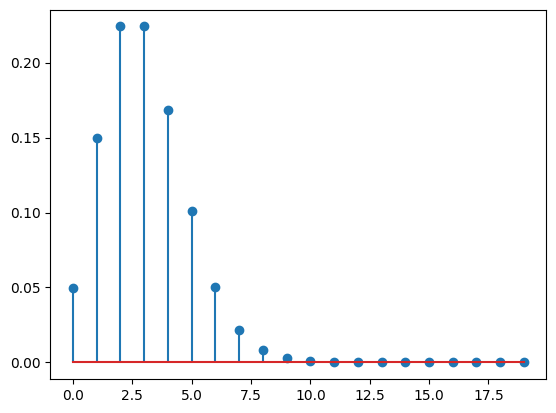

In [17]:
law = stats.poisson(3)
xplot = np.arange(20)
plt.stem(xplot,law.pmf(xplot))

Plot and comment the CDF of this distribution.

<IPython.core.display.Javascript object>

<span style="color:#33cc99">Solution:</span> 
```python

        xplot = np.linspace(0,20)
        plt.plot(xplot,law.cdf(xplot))
        # Remark that the CDF is a step function with jumps wherever the PMF is positive. The jump at x_i is pmf(x_i).
        
```

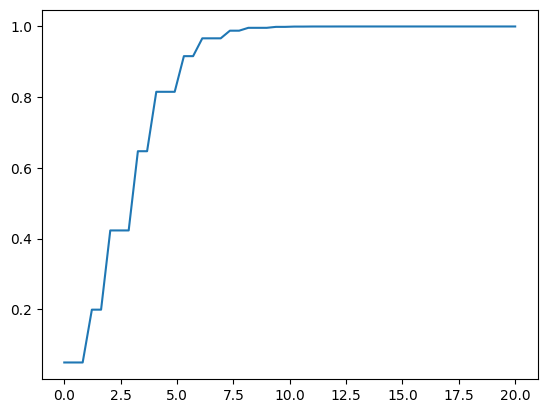

In [19]:
# Answer here
xplot = np.linspace(0,20)
plt.plot(xplot,law.cdf(xplot))
Q_2.solution()

### Question 3
Let $Y$ follow a standard Gaussian, what is $a$ such that $P(Y \le a )=0.95$ ? Compute a and verify that the value obtained verify indeed $P(Y\le a)=0.95$.

a is the quantile of level $95\%$ of the Gaussian distribution.

In [22]:
# Answer here
a = stats.norm.ppf(0.95)
check = stats.norm.cdf(a)

print(f"95th percentile (a): {a:.3f}")
print(f"CDF at a (should be 0.95): {check:.3f}")

95th percentile (a): 1.645
CDF at a (should be 0.95): 0.950


Now let $p_4$ be the probability that a standard exponential variable is smaller than $2$ and $p_5$ the probability that it is equal to $2$. Compute $p_4$ and $p_5$

In [26]:
p4 = stats.expon.cdf(2)
p5 = 0

In [27]:
Q_3.check()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct:</span> 



In [28]:
# Uncomment and execute this line to get a hint.
Q_3.hint()

<IPython.core.display.Javascript object>

<span style="color:#3366cc">Hint:</span> Be careful that for any continuous random variable, P(X = a ) = 0 for any a in R.

### Question 4
Represent on the same graph the densities of a Gaussian with means $0$ and variances $1$, $3$ and $10$. Add a legend.

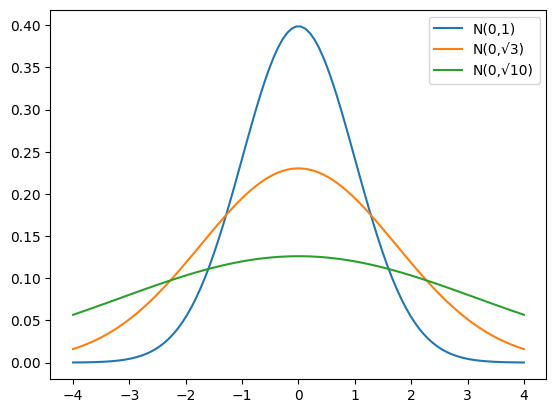

In [34]:
x = np.linspace(-4, 4, num=100)

plt.plot(x, stats.norm(0,1).pdf(x), label='N(0,1)')
plt.plot(x, stats.norm(0,np.sqrt(3)).pdf(x), label='N(0,√3)')
plt.plot(x, stats.norm(0,np.sqrt(10)).pdf(x), label='N(0,√10)')
plt.legend()

In [30]:
# Run the following line to check your solution.
Q_4.solution()

<IPython.core.display.Javascript object>

<span style="color:#33cc99">Solution:</span> 
```python

        plt.plot(x,norm(0,1).pdf(x), label='$\sigma^2=1$')
        plt.plot(x,norm(0,np.sqrt(3)).pdf(x), label='$\sigma^2=3$')
        plt.plot(x,norm(0,np.sqrt(10)).pdf(x), label='$\sigma^2=10$')
        
```

# Random Sampling, theoretical and empirical properties of a law.

The library numpy can generate a sample from most usual probability laws. There are functions to compute uniform, normal (Gaussian), Poisson distributions ...etc. They depend on the basic function random(), which generates a random float uniformly in the semi-open range [0.0, 1.0). Seeding a pseudo-random number generator gives it its first "previous" value. If you provide the same seed twice, you get the same sequence of numbers twice. A random seed is used to ensure that results are reproducible.

In [35]:
rng = np.random.RandomState(42) # Initialize with seed 42

Then, one can simulate random variables using this generator. Here we simulate $100$ i.i.d sample from a standard 2D normal random variable.

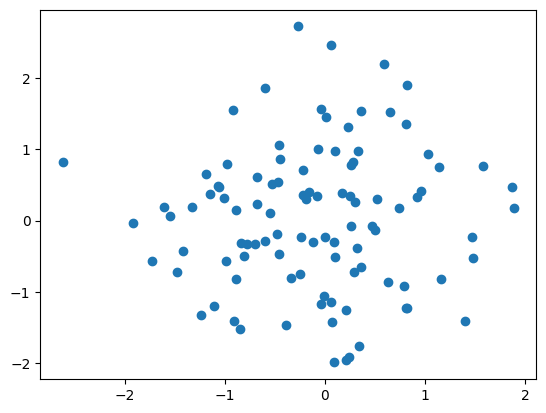

In [36]:
N = 100 # Sample size
X = rng.normal(size=[N,2]) # random sampling from normal distribution
plt.scatter(X[:,0],X[:,1]) # scatter plot of X

To generate numbers from a specific law the syntax is either of the type rng.name_of_the_law or you can also use the functions np.random.name_of_the_law and np.random.seed to initialize the generator.

### Question 5
Use a random generator initialized to the seed $42$ to sample $N$ points from a standard normal distribution in 2D and plot the result. Do the same with a random generator initialized with the seed $2020$ (replace the underscores ___ with your code). Is there a difference ?

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct:</span> 



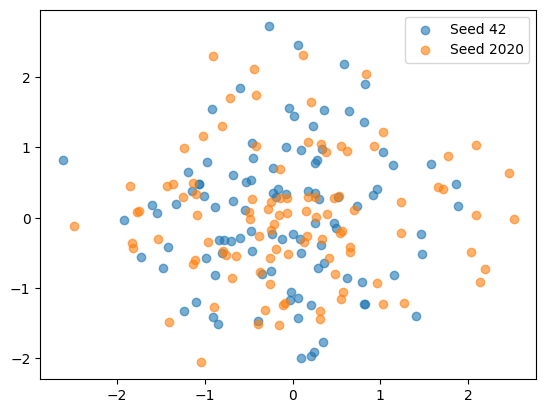

In [37]:
# Insert here a sample of a gaussian with seed 42
rng1 = np.random.RandomState(42)
X1 = rng1.normal(size=[N,2])
# Insert here a sample of a gaussian with seed 2020
rng2 = np.random.RandomState(2020)
X2 = rng2.normal(size=[N,2])
# Insert the plot functions here to plot X1 and X2
plt.scatter(X1[:,0], X1[:,1], label='Seed 42', alpha=0.6)
plt.scatter(X2[:,0], X2[:,1], label='Seed 2020', alpha=0.6)
plt.legend()
# Check your code, the following line should return correct.
Q_5.check()

As indicated previously, numpy allow us to sample from a varietry of law. For example one can sample from a discrete random variable with law Bernoulli or from a continue random variable with law Exponential. Let us first look at a Bernoulli distribution.

### Question 6
Sample $N=100$ i.i.d random variables from a Bernoulli distribution with parameter $p=0.3$. What is the theoretical mean of the distribution ? What is its theoretical variance ? Use numpy to compute its empirical mean and its empirical variance.

In [41]:
N = 100 # Size of the sample
p = 0.3 # parameter of the Bernoulli
X = np.random.binomial(1, p, size = N) # A Bernoulli(p) is a Binomial(1,p)
# Remark that when we don't use a RandomState instance here,
# the consequence is that the random seed is not fixed and executing several times this code will yield different result.

mu_th = p # theoretical mean
v_th = p * (1 - p) # theoretical variance


In [42]:
mu_emp = np.mean(X) # empirical mean
v_emp = np.var(X) # empirical variance
Q_6.check()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct</span>

In [43]:
Q_6.hint()

<IPython.core.display.Javascript object>

<span style="color:#3366cc">Hint:</span> See the documentation of np.mean and np.var

### Question 7
Now, we study the exponential distribution. Let $X$ be a random variable that follows the exponential distribution whose expectation is $1$.
Define a function that computes the expression of the PDF at a point $x$ (without using scipy). Plot the PDF.

Text(0.5, 1.0, 'Plot of the theoretical density of an exponential distribution')

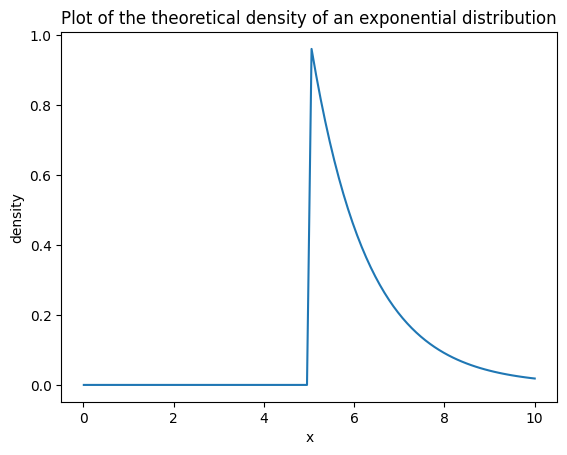

In [54]:
# Here is the density of an exponential of parameter $1$. This function is also in the library scipy.stats
def density_exp (x):
    x = np.array(x)
    return np.where(x >= 0, np.exp(-x), 0)

xplot = np.linspace(0.01,10,num=100) # this is a grid on [0,10] of 100 equidistant numbers. We will plot the curve at this points.
pdf_values = density_exp(x)
plt.plot(xplot, pdf_values)
plt.xlabel('x')
plt.ylabel('density')
plt.title('Plot of the theoretical density of an exponential distribution')

 Use np.random.exponential and numpy documentation to sample  $N=100$ points from an exponential distribution and represent these points on the graph using the code below. You can execute several time the cell for several different samples to visualize the alea.

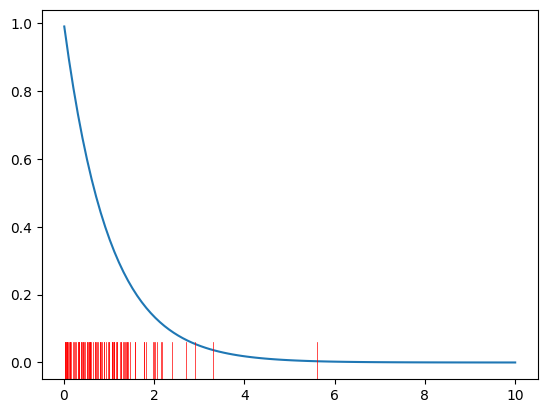

In [55]:
law = stats.expon(scale = 1 )

plt.plot(xplot,law.pdf(xplot))
X = law.rvs(size=100) # we generate a sample of size 100 from the exponential distribution
for Xi in X:
    plt.axvline(Xi, 0, 0.1, c='red', linewidth = 0.5) # we plot a vertical line for each sample point.

In [56]:
Q_7.check()

<IPython.core.display.Javascript object>

<span style="color:#cc3333">Incorrect:</span> Density is wrong

Using vertical bar on the abscisa to vizualize the data is not very nice, instead we can use an histogram that counts how many observations are in a given bin and plot a bar with a height corresponding to the number of points in the bin (renormalized by the total number of sample).

In [ ]:
plt.plot(xplot,law.pdf(xplot))
plt.hist(X, density=True)

# Statistical description of a database

We use theoretical laws to model real life. We have to examine each of the components found in the data to choose the laws that best represent them.

A Data frame is a two-dimensional data structure: data is aligned in a tabular fashion in rows and columns. Potentially columns are of different types.

In [ ]:
# Import of a dataset included in the library for research and education purpose.
df = sm.datasets.get_rdataset("ChickWeight", "datasets").data
# Description : The ChickWeight data frame has 578 rows and 4 columns from an experiment on the effect of diet on early growth of chicks.

In [ ]:
df.head() # print the first six lines of the dataset to see what it looks like.

### Question 8
How many features are categorical ? How many are numerical ?

In [ ]:
n_categorical = ___
n_numerical = ___
Q_8.check()

In [ ]:
# Diet is not really an integer, it is a type of diet, we must treat it as on object.
df['Diet']= df['Diet'].astype(object)

In [ ]:
df.describe(include="all")

In [ ]:
df['Diet'].value_counts()

A second step in the visualization of a database is to see the interactions between the features. To do that we use pairplots.

In [ ]:
sns.pairplot(df)

From the pairplot, we see that there seems to be some correlation between the time and the weight of the chicks. Formally, the correlation coefficient is defined by
$$Cor(X,Y)=\frac{Cov(X,Y)}{\sqrt{Var(X)Var(Y)}}.$$
this is a statistic that measures linear correlation between two variables X and Y. It has a value between +1 and −1. A value of +1 is total positive linear correlation, 0 is no linear correlation, and −1 is total negative linear correlation.

Let us compute the empirical correlation that we visualize using a heatmap.

In [ ]:
print(df.corr())
sns.heatmap(df.corr())

## Question 9
In this question we illustrate Simpson's paradox and confounding variables.

In [ ]:
df = sm.datasets.get_rdataset("Seatbelts", "datasets").data # Import of the database.
drivers = np.array(df['drivers']) #  monthly totals of car drivers in Great Britain killed or seriously injured Jan 1969 to Dec 1984.
petrol_price = np.array(df['PetrolPrice'])  # petrol price on the same months.

Print a scatter plot that shows the evolution of drivers as a function of petrol_price. Is there a correlation between drivers and petrol price ? Quantify by computing the correlation coefficient (using numpy.corrcoef).

In [ ]:
# Answer here

In the database df, we have access to one more information that is wether the law that makes seatbelts mandatory was in effect or not. This is the feature `df['law']`.
Print a scatter plot that shows the evolution of drivers as a function of petrol_price but this time using different color according to wether the seatbelt law was effective or not. Comment and quantify your findings with the computation of some correlation coefficients.
Is the petrol price really important to understand the evolution of the drivers ?

In [ ]:
# Answer here